## **Corporate clustering prototype**
This notebook analyses the `champions_group_data.csv` dataset. The goal is to build a prototype system that helps users derive actionable insights from company-level data by analysing firmographic, operational, and organizational attributes.

We will follow these steps:
1.  **Data Checking & Cleaning**: Load the data, check for missing values, and remove duplicates.
2.  **Exploratory Data Analysis (EDA)**: Investigate the features, their distributions, and their relationships with each other.
3.  **Preprocessing & Modeling**: Prepare the data for unsupervised modelling, using K-Means and Hierarchical Clustering to find natural groups.
4. **Cluster Interpretation**: Using Radar Charts to explain why a group exists.
5. **Building the tool**: Building a tool easily accesible for users to gain insights from big data.This will be done outside of this python notebook.

## **1. Importing libraries**

In [2132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

from sentence_transformers import SentenceTransformer

import pickle
import warnings
warnings.filterwarnings('ignore') 

sns.set(style="whitegrid")

## **2. Data Checking & Cleaning**

Prior to conducting the data analysis, the dataset will be examined for duplicate entries and missing values.

In [2133]:
#load data
data = pd.read_csv('../data/champions_group_data.csv')

In [2134]:
# Check initial shape of dataset
print(data.shape)

# Check for duplicates
data.duplicated().sum()

#check columns with missing values 
missing_counts = data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

(8559, 72)
Website                                  7934
Address Line 1                            343
City                                      514
State                                     515
State Or Province Abbreviation            735
Postal Code                               497
Phone Number                             6885
Ownership Type                           1082
Employees Single Site                       2
SIC Description                             1
8-Digit SIC Code                         5309
8-Digit SIC Description                  5309
NAICS Code                               5387
NAICS Description                        5387
NACE Rev 2 Code                          7045
NACE Rev 2 Description                   7047
Ticker                                   8555
Year Found                                774
Lattitude                                6647
Longitude                                6647
Parent Street Address                     109
Parents City           

There are 8559 rows (company sites) and 72 columns (variables) in the dataset. We found 0 duplicated rows and hence every entry in the dataset is unique.

## **3. Exploratory Data Analysis**

### 3.1 Univariate Analysis

Univariate analysis is conducted to examine each selected variable independently. This allows us to understand the variable’s distribution, central tendencies, variability, and any notable patterns or anomalies present in the data.

#### 3.1.1 Categorical Variables

**Country**

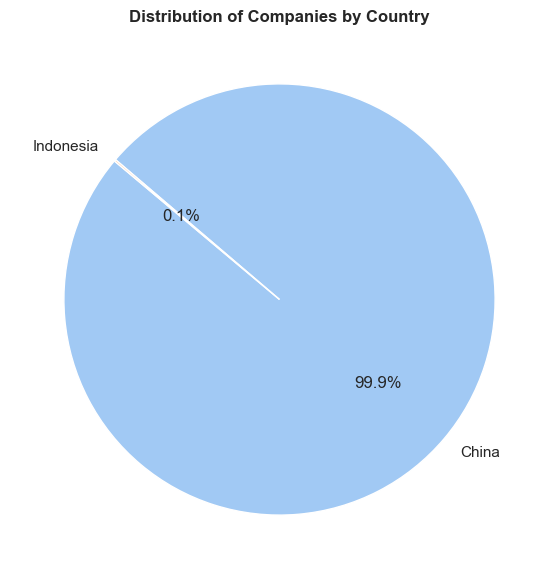

In [2135]:
data['Country'] = data['Country'].str.strip().str.title()
country_counts = data['Country'].value_counts()

colors = sns.color_palette('pastel')[0:len(country_counts)]

plt.figure(figsize=(7, 7))
plt.pie(country_counts, 
        labels=country_counts.index, 
        colors=colors,               
        autopct='%.1f%%',           
        startangle=140,
        wedgeprops={'edgecolor': 'white'}) 

plt.title('Distribution of Companies by Country', fontweight='bold')
plt.show()

Despite the `Country` variable being heavily skewed, it still provides valuable geographical location information for it's buyers. 

The country in which a company operates is an important deciding factor for data buyers and investors, as it provides critical context about the regulatory environment, economic conditions, and market dynamics the company is exposed to and can significantly influence their business performance and risk.

In addition, geographical location allows investors and market evaluators to identify growth opportunities tied to specific regions, compare companies within the same national market, and tailor their analyses to country-specific trends. For data buyers, the Country variable enables targeted market research, customer segmentation, and more accurate benchmarking, especially when focusing on companies operating in a particular country such as Indonesia.

**Entity Type & Ownership Type**

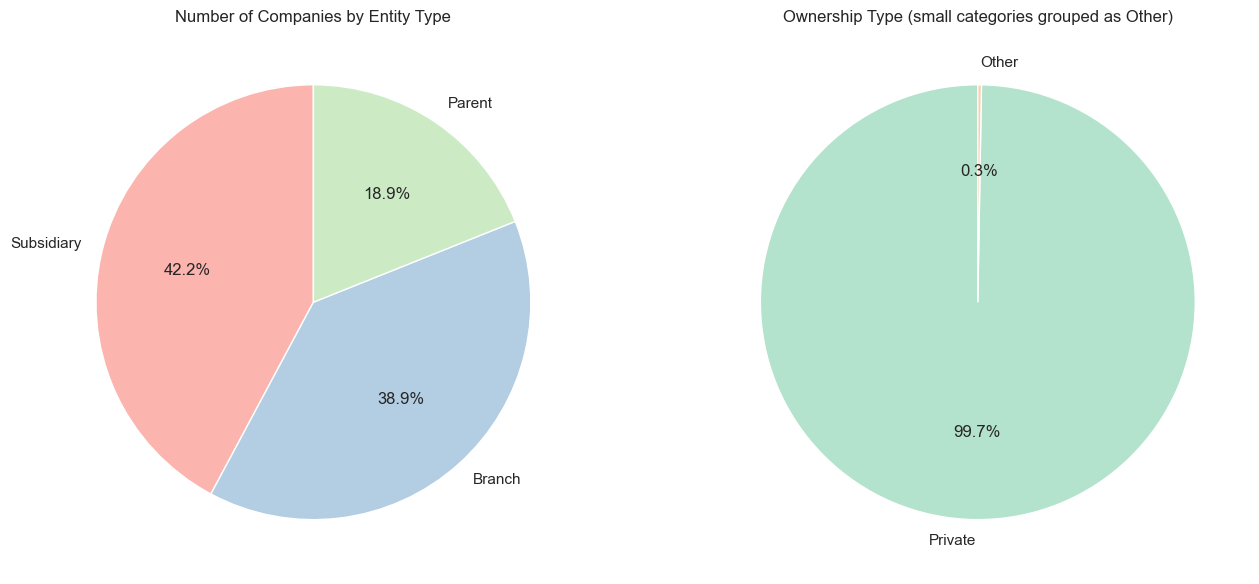

In [2136]:
# Count data
entity_counts = data['Entity Type'].value_counts()
ownership_counts = data['Ownership Type'].value_counts()

# Group smaller categories into "Other" 
threshold_percent = 1  # anything <1% will be grouped
ownership_percent = ownership_counts / ownership_counts.sum() * 100

# Keep large categories
ownership_grouped = ownership_percent[ownership_percent >= threshold_percent].copy()
# Add "Other" category
ownership_grouped['Other'] = 100 - ownership_grouped.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie for Entity Type
axes[0].pie(entity_counts, labels=entity_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
axes[0].set_title('Number of Companies by Entity Type')

# Pie for Ownership Type (using "Other")
axes[1].pie(ownership_grouped, labels=ownership_grouped.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel2.colors)
axes[1].set_title('Ownership Type (small categories grouped as Other)')

plt.tight_layout()
plt.show()


Since the remaining categories under `Ownership Type` represent very small proportions of the dataset, they were combined into an "Other" category. This grouping reduces sparsity and ensures that these rare categories do not disproportionately affect clustering results.

**Industry Codes**

In the dataset, there are 3 different industry classification code systems - SIC, NASIC, ANZSIC. We will use the visualizations to determine the most suitable industry code to use. Industry codes classify companies into sectors, enabling meaningful grouping for analysis and benchmarking. We select the code with the highest data coverage to ensure consistency and completeness in our segmentation.

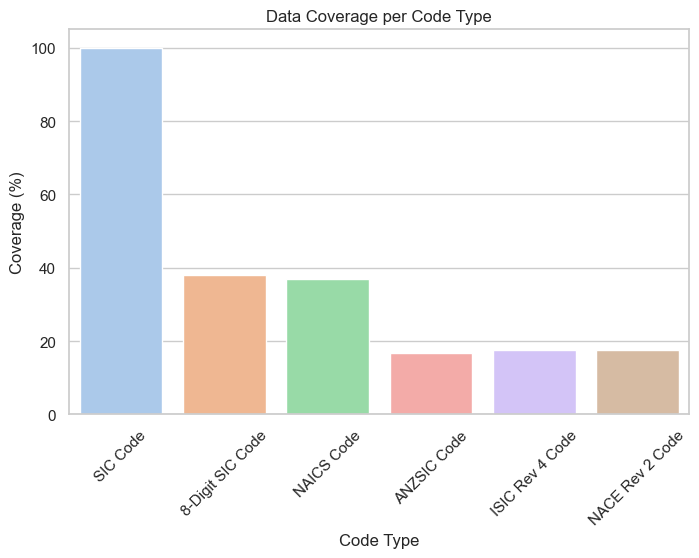

In [2137]:
code_columns = [
    'SIC Code',
    '8-Digit SIC Code',
    'NAICS Code',
    'ANZSIC Code',
    'ISIC Rev 4 Code',
    'NACE Rev 2 Code'
]

coverage = (1 - data[code_columns].isna().mean()) * 100  # % of non-missing
plt.figure(figsize=(8,5))
sns.barplot(x=coverage.index, y=coverage.values, palette='pastel')
plt.ylabel('Coverage (%)')
plt.xlabel('Code Type')
plt.title('Data Coverage per Code Type')
plt.xticks(rotation=45)
plt.show()


Since `SIC Code` is 100% populated in the dataset, we will use SIC code to classify the industries.

**Legal Status**

In [2138]:
legal_status_counts = data['Legal Status'].value_counts().sort_index()

# Combine into a table
legal_status_table = pd.DataFrame({
    'Count': legal_status_counts
})

legal_status_table

,Count
Legal Status,
0.0,873
3.0,7453
8.0,85
12.0,30
13.0,27
50.0,7
100.0,1
101.0,54
120.0,27


The `Legal Status` variable indicates a potential classification of firms. However, without supporting documentation to define the categories, the variable cannot be meaningfully interpreted and is therefore excluded.

**Electronics**

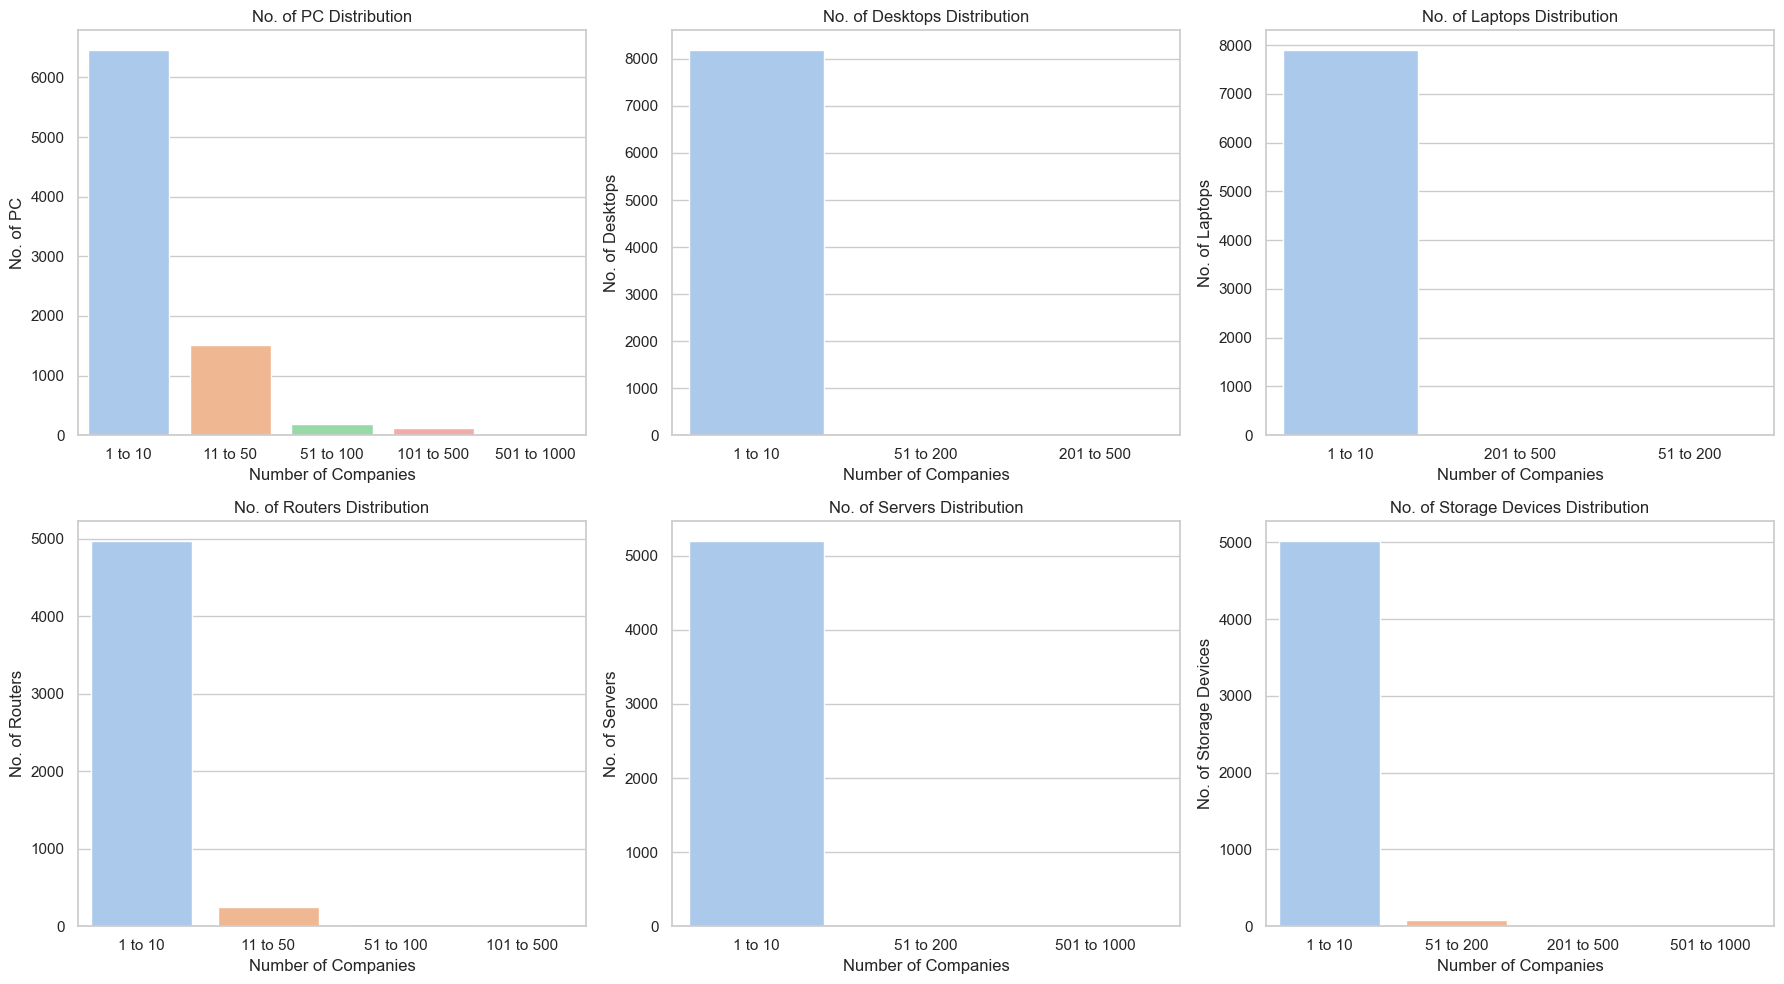

In [2139]:
hardware_cols = [
    'No. of PC', 'No. of Desktops', 'No. of Laptops',
    'No. of Routers', 'No. of Servers', 'No. of Storage Devices'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, hardware_cols):
    sns.countplot(
        x=col,              
        data=data,
        order=data[col].value_counts().index,  
        ax=ax, 
        palette='pastel'
    )
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('Number of Companies')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

The dominance of low-count categories across all variables suggests a structurally imbalanced dataset, with a small number of large organisations exerting disproportionate influence on numerical features.

#### 3.1.2 Numerical Variables

**Corporate Family Members, Employees Single Site, Employees Total**

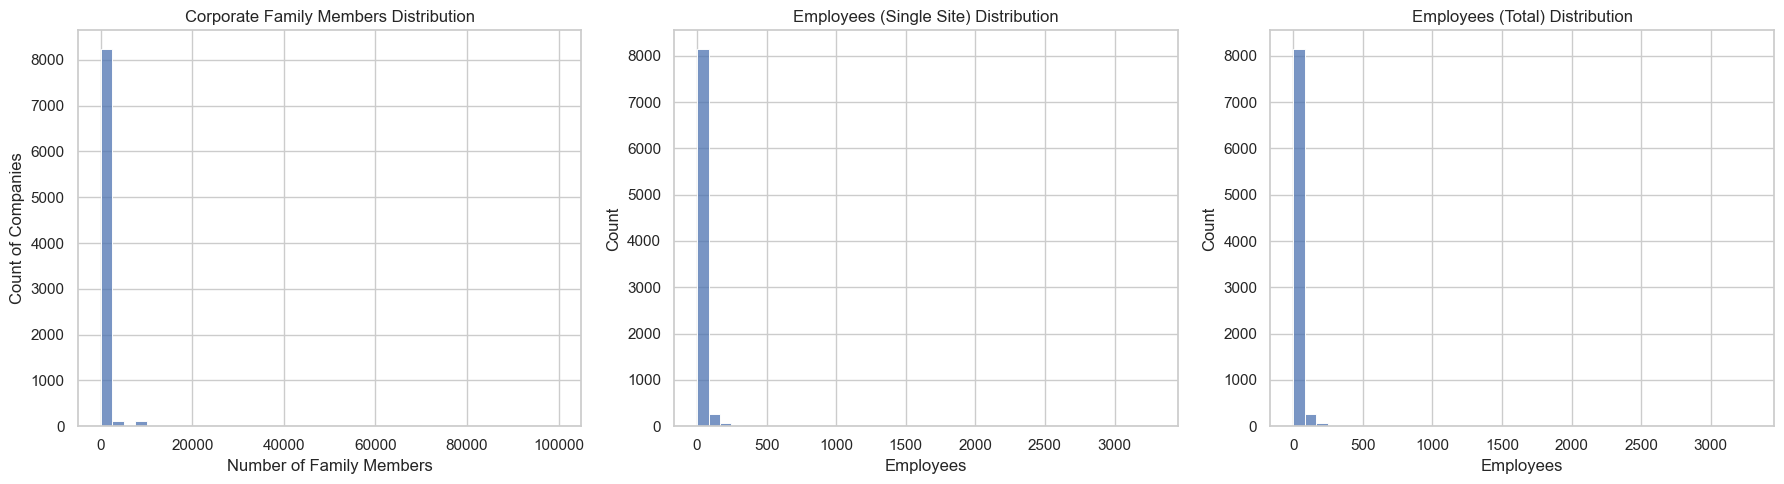

In [2140]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data['Corporate Family Members'].dropna(),
    bins=40,
    ax=axes[0], 
    palette='pastel'
)
axes[0].set_title('Corporate Family Members Distribution')
axes[0].set_xlabel('Number of Family Members')
axes[0].set_ylabel('Count of Companies')

sns.histplot(
    data['Employees Single Site'].dropna(),
    bins=40,
    ax=axes[1], 
    palette='pastel'
)
axes[1].set_title('Employees (Single Site) Distribution')
axes[1].set_xlabel('Employees')

sns.histplot(
    data['Employees Total'].dropna(),
    bins=40,
    ax=axes[2],
    palette='pastel'
)
axes[2].set_title('Employees (Total) Distribution')
axes[2].set_xlabel('Employees')

plt.tight_layout()
plt.show()

Due to their high right-skewness, the variables `Corporate Family Members`, `Employees Single Site`, and `Employees Total` should be scaled to mitigate the effect of extreme values and ensure comparability across features.

### 3.2 Bivariate Analysis

Bivariate analysis will be used to explore relationships between 2 variables and find possible correlated variables.

#### 3.2.1 IT Spend & IT Budget

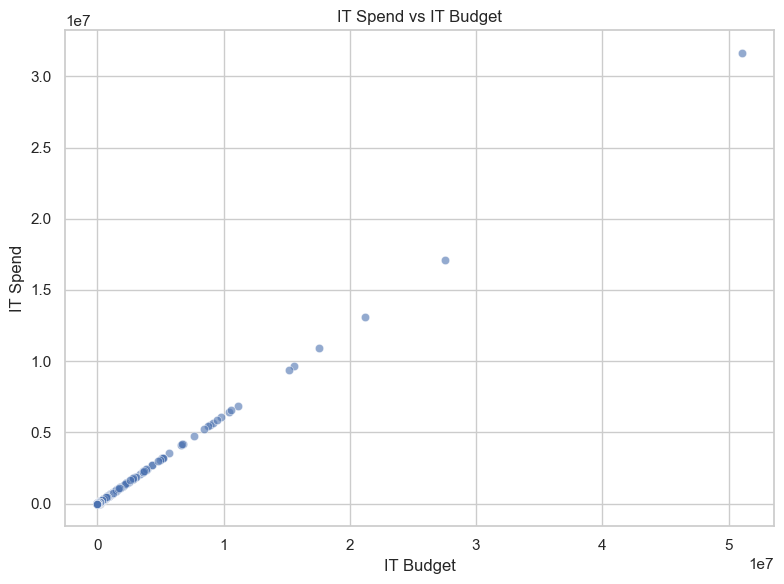

In [2141]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x="IT Budget",
    y="IT spend",
    alpha=0.6
)

plt.title("IT Spend vs IT Budget")
plt.xlabel("IT Budget")
plt.ylabel("IT Spend")
plt.tight_layout()
plt.show()


The near-diagonal pattern indicates that IT spend increases proportionally with IT budget, suggesting that both variables capture the same underlying scale of IT investment and are therefore largely redundant. 

#### 3.2.2 Market Value Vs Revenue

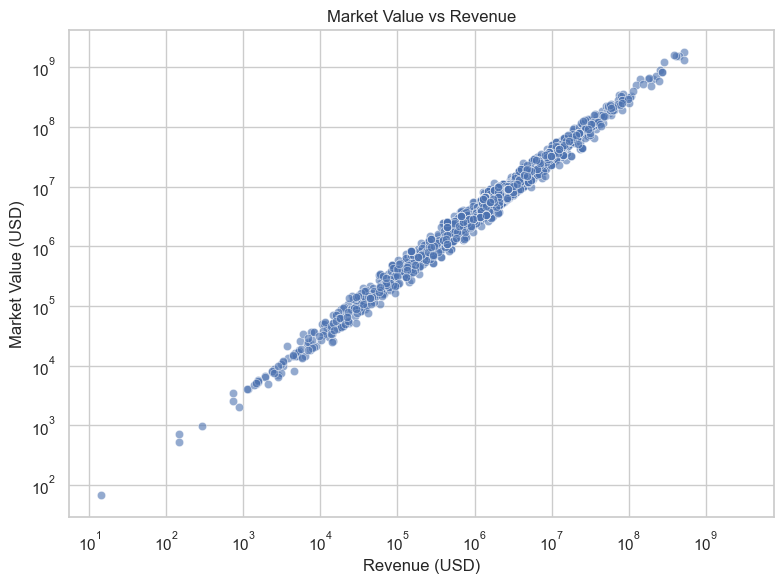

In [2142]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x="Revenue (USD)",
    y="Market Value (USD)",
    alpha=0.6
)

# Log scale is strongly recommended
plt.xscale("log")
plt.yscale("log")

plt.title("Market Value vs Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Market Value (USD)")
plt.tight_layout()
plt.show()


A logarithmic scale was used because Market Value and Revenue span several orders of magnitude. Applying a log transformation reduces the influence of extreme values, improves interpretability across firms of different sizes, and makes proportional (multiplicative) relationships easier to observe.

Similar to IT Budget and IT Spend, the relationship between Market Value and Revenue is approximately linear.

#### 3.2.3 Entity Type Vs Employees Single Site

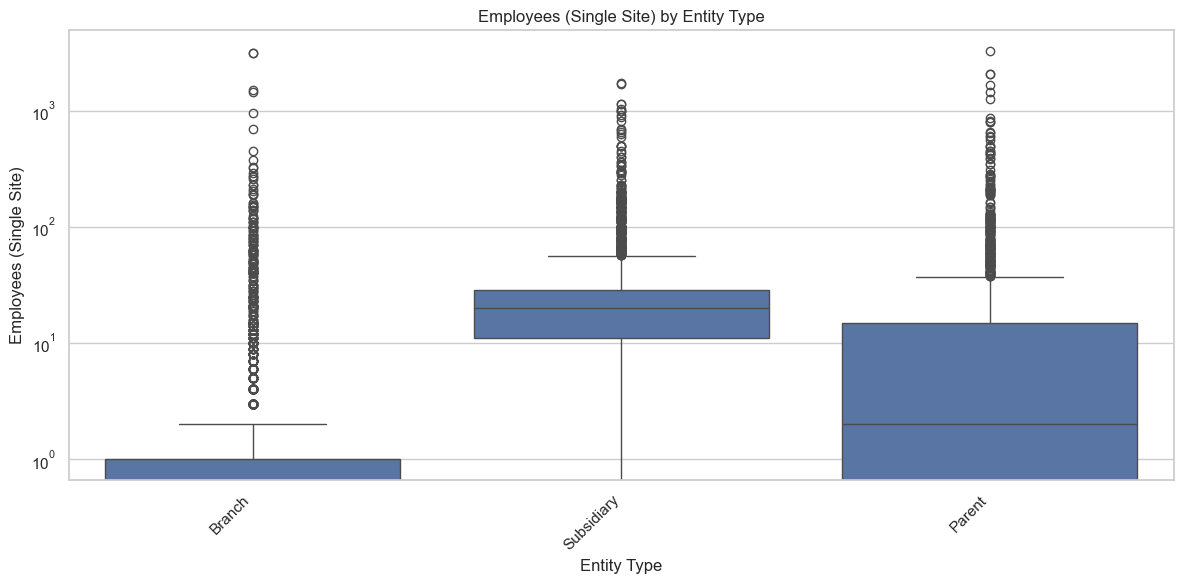

In [2143]:
#boxplot on log scale 

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=data,
    x="Entity Type",
    y="Employees Single Site"
)

plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Employees (Single Site) by Entity Type")
plt.ylabel("Employees (Single Site)")
plt.xlabel("Entity Type")
plt.tight_layout()
plt.show()


The boxplot reveals systematic differences in typical site size across entity types, with subsidiaries generally employing more staff per site, while branches are predominantly small but exhibit a long tail of large outliers. This indicates that Employees (Single Site) contains meaningful segmentation signal but is highly right-skewed and heterogeneous.

For clustering purposes, we therefore retain Employees (Single Site) as a feature. The number of employees at a site is a key variable for data buyers as it reflects organisational scale, purchasing potential, and expected demand for technology and enterprise services. Logarithmic transformation will be applied to the feature to reduce the influence of extreme values and ensure that relative differences in site size, rather than absolute counts, drive distance calculations. Entity Type is retained as contextual information rather than a primary size proxy, as substantial overlap exists across categories.

### 3.3 Multivariate Analysis

#### 3.3.1 Spearson Correlation Matrix

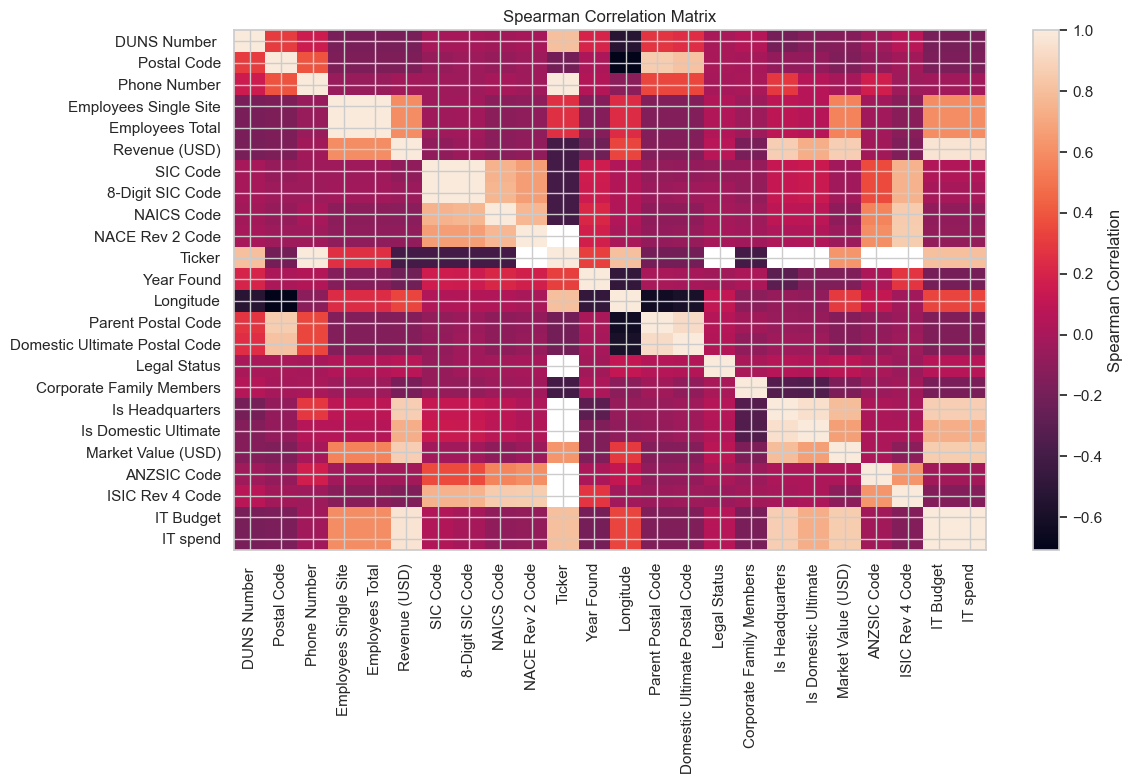

In [2144]:
# keep only numeric features
numeric_df = data.select_dtypes(include="number")

spearman_corr = numeric_df.corr(method="spearman")

plt.figure(figsize=(12, 8))
plt.imshow(spearman_corr, aspect="auto")
plt.colorbar(label="Spearman Correlation")
plt.xticks(range(len(spearman_corr.columns)), spearman_corr.columns, rotation=90)
plt.yticks(range(len(spearman_corr.columns)), spearman_corr.columns)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()


The Spearman correlation matrix corroborates the bivariate analysis by showing strong monotonic correlations among scale-related variables such as revenue, market value, and IT expenditure. This supports the feature reduction and ratio-based transformations applied prior to clustering.

## **4. Feature Engineering**
Feature engineering is applied to ensure meaningful clustering by removing redundant variables, creating ratio-based features, applying scale and log transformations to address skewness and magnitude differences, handling missing values appropriately, and standardizing features so that no single variable disproportionately influences distance calculations.

### 4.1 Reducing Dimensionality

Since there are 72 columns, we will be dropping some columns. 

In [2145]:
def audit_data_quality(df):
    summary_data = []
    
    for col in df.columns:
        missing_pct = df[col].isnull().mean() * 100
        
        unique_count = df[col].nunique()
        
        value_counts_norm = df[col].value_counts(normalize=True, dropna=True)
        if not value_counts_norm.empty:
            top_val = value_counts_norm.index[0]
            dominance_pct = value_counts_norm.iloc[0] * 100
        else:
            top_val = "Empty"
            dominance_pct = 100.0
            
        summary_data.append({
            'Column': col,
            'Missing (%)': round(missing_pct, 2),
            'Unique Values': unique_count,
            'Top Value': str(top_val)[:30],  
            'Dominance (%)': round(dominance_pct, 2),
            'Type': df[col].dtype
        })
    
    quality_df = pd.DataFrame(summary_data)

    useless_cols = quality_df[quality_df['Dominance (%)'] > 97]['Column'].tolist()
    
    high_missing_cols = quality_df[
        (quality_df['Missing (%)'] > 70)
    ]['Column'].tolist()
    
    return quality_df, list(set(useless_cols + high_missing_cols))

quality_report, suggested_drops = audit_data_quality(data)

print("Columns with > 97% Dominance:")
print(quality_report[quality_report['Dominance (%)'] > 97].sort_values(by='Dominance (%)', ascending=False))

print("\nColumns with > 70% Missing Values:")
missing_series = quality_report.set_index('Column')['Missing (%)']
print(missing_series[missing_series > 70].sort_values(ascending=False))

print(f"\nSuggested drops ({len(suggested_drops)} columns)")
print(suggested_drops)

Columns with > 97% Dominance:
                              Column  Missing (%)  Unique Values  \
10                            Region         0.00              1   
59                   Fiscal Year End         0.01              1   
58              Manufacturing Status        96.95              1   
51  Company Status (Active/Inactive)         0.00              1   
49          Registration Number Type        99.91              1   
70                    No. of Servers        39.13              3   
8                            Country         0.00              2   
68                    No. of Laptops         7.47              3   
12                    Ownership Type        12.64              5   
67                   No. of Desktops         3.98              3   
34             Parent Country/Region         0.00              9   
41      Global Ultimate Country Name         0.00             14   
71            No. of Storage Devices        40.11              4   

                 

We will proceed with dropping `Region`, `Company Status`, and `Fiscal Year End`. These features exhibit near-zero variance (almost 100% identical values), meaning they offer no discriminatory power for our analysis. 

As `SIC code` is used as the standard industry classification, alternative industry codes are excluded. We also drop attributes that do not contribute to clustering or LLM-based analysis, including address-related fields and detailed information on related companies, retaining only their name and basic location information.

Additionally, we will remove columns with >70% missing data. Given the high sparsity, these features lack critical information, and statistical imputation would likely introduce significant noise rather than recover meaningful signals.

However, despite statistical skew or missingness, we will explicitly retain high-value commercial indicators. These includes the Country, Parent Country/Region, Ownership Type columns require more analysis since they may be useful for a data buyer who is interested in companies located in other countries apart from the majority which is China or a company belonging to public sector etc.

Furthermore, IT Infrastructure columns such as the No. of Desktops, No. of Servers may be a proxy for Digital Maturity. Hence, even if sparse, the presence of this data indicates a tech-forward company, which is a key selling point for data buyers. Thus, we will not remove them as well.

In [2146]:
suggested_drops.extend(['Address Line 1', 'State Or Province Abbreviation', 'Postal Code', '8-Digit SIC Code', '8-Digit SIC Description', 
                        'NAICS Code','NAICS Description', 'Parent Street Address', 'Parent State/Province Abbreviation', 'Parent Postal Code', 
                        'Global Ultimate Street Address', 'Ultimate State/Province Abbreviation', 'Global Ultimate Postal Code',
                        'Domestic Ultimate Street Address', 'Domestic Ultimate State Abbreviation', 'Domestic Ultimate Postal Code', 'Registration Number',
                        'Legal Status'
                       ])

cols_to_drop = set(suggested_drops) - {'Country', 'Parent Country/Region', 'Ownership Type', 'No. of Desktops', 'No. of Laptops', 'No. of Servers', 'No. of Storage Devices', 'Website'}
cols_to_drop = list(cols_to_drop)
print(f"\nFinal columns to drop ({len(cols_to_drop)} columns):")
print(cols_to_drop)


Final columns to drop (37 columns):
['Domestic Ultimate Street Address', 'Ultimate State/Province Abbreviation', '8-Digit SIC Code', 'Phone Number', 'ANZSIC Description', 'Company Status (Active/Inactive)', 'Global Ultimate Street Address', 'Legal Status', 'Is Headquarters', 'Manufacturing Status', 'Postal Code', 'Parent Postal Code', 'ANZSIC Code', 'Global Ultimate Country Name', 'NAICS Description', 'Ticker', 'Registration Number', '8-Digit SIC Description', 'NAICS Code', 'Region', 'Address Line 1', 'Global Ultimate Postal Code', 'Registration Number Type', 'Is Domestic Ultimate', 'NACE Rev 2 Code', 'NACE Rev 2 Description', 'Fiscal Year End', 'Franchise Status', 'Parent State/Province Abbreviation', 'Domestic Ultimate Postal Code', 'Lattitude', 'ISIC Rev 4 Description', 'Longitude', 'Parent Street Address', 'Domestic Ultimate State Abbreviation', 'ISIC Rev 4 Code', 'State Or Province Abbreviation']


In [2147]:
dropped_data = data.drop(columns=cols_to_drop)

print(f"\nFinal list of columns to keep ({len(dropped_data.columns)} columns):")
for col in dropped_data.columns:
    print(f"- {col}")



Final list of columns to keep (35 columns):
- DUNS Number 
- Company Sites
- Website
- City
- State
- Country
- Entity Type
- Ownership Type
- Employees Single Site
- Employees Total
- Revenue (USD)
- SIC Code
- SIC Description
- Year Found
- Parent Company
- Parents City
- Parent State/Province
- Parent Country/Region
- Global Ultimate Company
- Global Ultimate City Name
- Global Ultimate State/Province
- Domestic Ultimate Company
- Domestic Ultimate City Name
- Domestic Ultimate State/Province Name
- Company Description
- Corporate Family Members
- Market Value (USD)
- IT Budget
- IT spend
- No. of PC
- No. of Desktops
- No. of Laptops
- No. of Routers
- No. of Servers
- No. of Storage Devices


#### 3.1.2 PCA (Principal Component Analysis)

In [2148]:
# similarly, keep only numeric features
numeric_df_pca = dropped_data.select_dtypes(include="number")

# PCA also requires us to remove NaNs, we do so only for EDA
numeric_df_pca = numeric_df_pca.dropna()

# scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df_pca)
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

explained_variance = pd.DataFrame({
    "Principal Component": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance Ratio": pca.explained_variance_ratio_.cumsum()
})

print(explained_variance)


   Principal Component  Explained Variance Ratio
0                    1                  0.280790
1                    2                  0.474426
2                    3                  0.589846
3                    4                  0.691697
4                    5                  0.788591
5                    6                  0.866373
6                    7                  0.940173
7                    8                  0.999999
8                    9                  1.000000
9                   10                  1.000000


PCA was used to assess the underlying dimensional structure of the data by transforming correlated variables into a smaller set of uncorrelated components that capture maximum variance. In this dataset, variance is distributed across multiple components, with approximately 5–7 principal components required to explain most of the variability. This reinforces the  bivariate analyses, which showed strong linear and monotonic relationships among scale-related features. Together, these results confirm feature redundancy and support dimensionality reduction and feature consolidation prior to clustering.

### 3.2 Transforming Features

#### 3.2.1 **SIC Codes**
SIC (Standard Industrial Classification) codes categorize firms by industry in a hierarchical manner. Truncating the two digits captures broader industry sectors while reducing sparsity and noise from overly granular classifications, making the categories more suitable for exploratory analysis and cluster interpretation.

In [2149]:
# Ensure SIC Code is string
dropped_data["SIC Code"] = dropped_data["SIC Code"].astype(str).str.strip()

# Remove last 2 digits
dropped_data["SIC_2digit"] = dropped_data["SIC Code"].str[:-2]

# Concatenate unique descriptions per 2-digit SIC
sic_2digit_desc = (
    dropped_data
    .dropna(subset=["SIC_2digit", "SIC Description"])
    .groupby("SIC_2digit")["SIC Description"]
    .apply(lambda x: ", ".join(sorted(set(x))))
    .reset_index(name="SIC_2digit_Description")
)

# Merge back to original dataframe
dropped_data = dropped_data.merge(
    sic_2digit_desc,
    on="SIC_2digit",
    how="left"
)

#unique sic 2 digits
unique_sic_2digit = dropped_data["SIC_2digit"].dropna().unique()
unique_sic_2digit

<StringArray>
['50', '56', '20',  '1', '65', '80', '12', '59', '73', '34', '54', '75', '41',
 '52', '58',  '2', '55', '87', '17', '79', '42', '36', '89', '28', '47', '15',
 '62', '86', '51', '99', '82', '32', '76', '63', '91', '35', '48', '33', '49',
 '30', '83', '72', '57', '70', '96', '37', '61', '16', '67', '53', '39', '23',
 '26',  '9', '38', '81', '88', '60',  '7', '64', '78', '44', '22', '29', '84',
 '95', '27', '25', '10', '24', '45',  '8', '14', '13', '31', '40']
Length: 76, dtype: str

The SIC 2 digit code is then frequency encoded and also grouped into even broader categories based on our observations of the industries.

In [2150]:
#frequency encoding for SIC 2 digit 
freq_map = dropped_data['SIC_2digit'].value_counts(normalize=True)
dropped_data['SIC_2digit_encoded'] = dropped_data['SIC_2digit'].map(freq_map)

#group them into even broader categories before encoding
# SIC 2 digit	Broad category
# 01–09	  Agriculture, Forestry, Fishing
# 10–14	  Mining
# 15–17	  Construction
# 20–39	  Manufacturing
# 40–49	  Transportation & Utilities
# 50–51	  Wholesale Trade
# 52–59	  Retail Trade
# 60–67	  Finance, Insurance, Real Estate
# 70–89	  Services
# 91–99   Public Administration

bins = [0, 9, 14, 17, 39, 49, 51, 59, 67, 89, 99]
labels = [
    "Agriculture, Forestry, Fishing",
    "Mining",
    "Construction",
    "Manufacturing",
    "Transportation & Utilities",
    "Wholesale Trade",
    "Retail Trade",
    "Finance, Insurance, Real Estate",
    "Services",
    "Public Administration"
]

#change sic 2 digit to numeric
dropped_data["SIC_2digit"] = pd.to_numeric(
    dropped_data["SIC_2digit"],
    errors="coerce"
)

dropped_data["SIC_broad_category"] = pd.cut(
    dropped_data["SIC_2digit"],
    bins=bins,
    labels=labels,
    right=True
)


#### 3.2.2 **Revenue**
As seen in previous EDA, Market Value and Revenue is approximately linear. Hence,we will drop Market Value (USD) and keep Revenue since revenue is a better approximation of its business activity , not influenced by stock market speculations. The revenue is then subsequently log-transformed and scaled to reduce skewness and prevent extreme values from disproportionately influencing clustering results.

In [2151]:
#drop market value
dropped_data = dropped_data.drop(columns=["Market Value (USD)"])

#apply log transformation
dropped_data["revenue_log"] = np.log1p(dropped_data['Revenue (USD)'])

#scaling 
scaler = StandardScaler()

dropped_data["revenue_log_scaled"] = scaler.fit_transform(
    dropped_data[["revenue_log"]]
)


#### 3.2.3 **IT Spend - IT Budget Ratio**
Similarly, IT spend increases proportionally with IT budget. To avoid over-representing this scale effect in clustering, we will drop IT budget and keep IT spend since IT spend is an actualised operational investment. The IT spend is also log transformed and scaled to reduce skewness and disproportionality.

In [2152]:
#drop IT Budget 
dropped_data = dropped_data.drop(columns=["IT Budget"])

#apply log transformation to IT spend
dropped_data["IT spend_log"] = np.log1p(dropped_data['IT spend'])

#scaling
dropped_data["IT spend_log_scaled"] = scaler.fit_transform(
    dropped_data[["IT spend_log"]]
)

dropped_data = dropped_data.drop(
    columns=["IT spend_log", "revenue_log"]
)


#### 3.2.4 **Total Devices**
All device-related variables were combined into a single aggregated feature to capture overall IT footprint. Categorical device ranges were first converted into numerical values using midpoints to obtain approximate counts. 

In [2153]:
## Number of IT devices put into categorical ranges
device_cols = [
    "No. of PC",
    "No. of Desktops",
    "No. of Laptops",
    "No. of Routers",
    "No. of Servers",
    "No. of Storage Devices"
]

# Convert to numerical values using midpoints
bin_map = {
    "1 to 10": 5,
    "11 to 50": 30,
    "51 to 100": 75,
    "101 to 500": 300,
    "501 to 1000": 750
}

# Mapping
for col in device_cols:
    dropped_data[col] = dropped_data[col].map(bin_map)



Missing values for IT devices were imputed using a calculated device-per-employee ratio, while accounting for company size and industry characteristics. 

In [2154]:
effective_employees = dropped_data['Employees Single Site'].clip(lower=1)

bins = pd.qcut(
    dropped_data['Employees Single Site'],
    q=4,
    duplicates='drop'
)

dropped_data['employee_size_bin'] = bins.cat.rename_categories(
    ['small', 'medium', 'large', 'xlarge'][:bins.cat.categories.size]
)

# 1. create device-per-employee ratios
for col in device_cols:
    dropped_data[f'{col}_ratio'] = dropped_data[col] / effective_employees

# 2. impute ratios with fallback strategy
for col in device_cols:
    ratio_col = f'{col}_ratio'

    # sic+size level
    level1 = dropped_data.groupby(
        ['SIC_2digit', 'employee_size_bin']
    )[ratio_col].transform('median')

    # only sic
    level2 = dropped_data.groupby(
        'SIC_2digit'
    )[ratio_col].transform('median')

    # global 
    global_median = dropped_data[ratio_col].median()

    final_ratio = level1.fillna(level2).fillna(global_median)

    # convert
    dropped_data[col] = dropped_data[col].fillna(
        final_ratio * effective_employees
    )

# 3. remove temp ratio columns
dropped_data.drop(
    columns=[f'{col}_ratio' for col in device_cols],
    inplace=True
)


A missingness indicator column was still added to preserve information about incomplete reporting despite the imputation. The resulting sum of all total IT devices was log-transformed to reduce skewness and prevent large firms from dominating distance-based clustering.

In [2155]:
# Aggregate device count
dropped_data["total_devices"] = dropped_data[device_cols].sum(
    axis=1,
    min_count=4
)

# Missingness indicator - if more than 2 devices are unrecorded
dropped_data["total_devices_missing"] = (
    dropped_data["total_devices"].isna().astype(int)
)
# Log-transform total devices (safe for skewed distributions)
dropped_data["log_total_devices"] = np.log1p(dropped_data["total_devices"])

# If more than 2 devices are missing, total is missing


# Drop original device columns and unlogged total
dropped_data = dropped_data.drop(
    columns=device_cols + ["total_devices"]
)

#### 3.2.5 **Is Global Ultimate**
We noticed that many of the companies were Global Ultimate Companies as well. Hence, a new boolean column is created to indicate whether these companies are Global Ultimate Companies.

In [2156]:
dropped_data['Is Global Ultimate Company'] = (dropped_data['Company Sites'] == dropped_data['Global Ultimate Company']).astype(int)

#### 3.2.5 **Is Domestic Ultimate**
Since the original Is Domestic Ultimate column had over 70% missing values and was dropped, a new boolean variable was created to infer whether a company is a domestic ultimate using 'Domestic Ultimate Company'column.

In [2157]:
dropped_data['Is Domestic Ultimate Company'] = (dropped_data['Company Sites'] == dropped_data['Domestic Ultimate Company']).astype(int)

#### 3.2.6 **Ownership Type and Entity Type**
As demonstrated in 3.1.1, we will combine the non-private categories into Other. Both Entity Type and Ownership Type is then one-hot encoded.

In [2158]:
# Keep 'Private' and combine non-Private categories into 'Other'
dropped_data['Ownership Type'] = dropped_data['Ownership Type'].replace(
    ['Nonprofit', 'Partnership', 'Public Sector', 'Non-Corporates'], 'Other'
)

# Check counts
dropped_data['Ownership Type'].value_counts()

# One hot Encoding for Nominal features
nominal_cols = ['Entity Type', 'Ownership Type']
encoded = pd.get_dummies(dropped_data[nominal_cols], drop_first=False)

encoded.head()

,Entity Type_Branch,Entity Type_Parent,Entity Type_Subsidiary,Ownership Type_Other,Ownership Type_Private
0,True,False,False,False,True
1,False,False,True,False,True
2,False,False,True,False,True
3,False,True,False,False,True
4,False,True,False,False,True


#### 3.2.7 **Country**
`Country` column will be label encoded to produce a binary column since there are only two countries.

In [2159]:

# Encode country
le = LabelEncoder()
encoded['Country_encoded'] = le.fit_transform(
    dropped_data[['Country']]
)

# Check
encoded.head()


,Entity Type_Branch,Entity Type_Parent,Entity Type_Subsidiary,Ownership Type_Other,Ownership Type_Private,Country_encoded
0,True,False,False,False,True,0
1,False,False,True,False,True,0
2,False,False,True,False,True,0
3,False,True,False,False,True,0
4,False,True,False,False,True,0


In [2160]:
# Combining encoded data with dropped_data
cols_to_drop = ['Entity Type', 'Ownership Type', 'SIC_2digit']
dropped_data = dropped_data.drop(columns=cols_to_drop)
dropped_data = pd.concat([dropped_data, encoded], axis=1)
dropped_data.head()

,DUNS Number,Company Sites,Website,City,State,Country,Employees Single Site,Employees Total,Revenue (USD),SIC Code,...,total_devices_missing,log_total_devices,Is Global Ultimate Company,Is Domestic Ultimate Company,Entity Type_Branch,Entity Type_Parent,Entity Type_Subsidiary,Ownership Type_Other,Ownership Type_Private,Country_encoded
0,639677726,"Zyf Lopsking Material Technology Co., Ltd. No....",NaN,Suzhou,Jiangsu,China,1.0,1,0,5051,...,0,3.157000,0,0,True,False,False,False,True,0
1,547756179,"Beijing Kaishi Lide Commerce And Trade Co., Lt...",NaN,Beijing,Beijing,China,20.0,20,311166,5651,...,0,3.433987,0,0,False,False,True,False,True,0
2,728834216,Keshan Shengren Potato Industry Processing Co....,NaN,Qiqihar,Heilongjiang,China,89.0,89,2414036,2037,...,0,4.025352,0,0,False,False,True,False,True,0
3,728791839,Zuoquan County Yuanfeng Agriculture Technology...,NaN,Jinzhong,Shanxi,China,0.0,0,306060,191,...,0,2.024900,1,1,False,True,False,False,True,0
4,728889244,Zuoquan County Tianxin Real Estate Development...,NaN,Jinzhong,Shanxi,China,2.0,2,1167456,6552,...,0,3.433987,1,1,False,True,False,False,True,0


### 3.3.2 **Year Found**

In [2161]:
dropped_data['Year Found_scaled'] = StandardScaler().fit_transform(dropped_data[['Year Found']])

#new column stating year range is missing
dropped_data['Year missing'] = dropped_data['Year Found_scaled'].isna().astype(int)

# fill missing year found with median bin
median_val = dropped_data['Year Found'].median()
dropped_data['Year Found_scaled'] = dropped_data['Year Found_scaled'].fillna(median_val)

`Year Found` column is scaled. Missing values for Year Found is imputed using the median value. A missingness column is then created to track incomplete information.

### 3.2.8 **City, State, Employees Single Site**

Rows with missing city and state and number of employees information were removed. It was not possible to infer geographical location from other available variables.

In [2162]:
dropped_data = dropped_data.dropna(
    subset=['City', 'State', 'Employees Single Site'],
    how='any'
)

### 3.4 Inspection of final cleaned dataset

The final cleaned dataset consists of 8042 rows and 42 columns.

In [2163]:

print(dropped_data.columns)
print(dropped_data.shape)

Index(['DUNS Number ', 'Company Sites', 'Website', 'City', 'State', 'Country',
       'Employees Single Site', 'Employees Total', 'Revenue (USD)', 'SIC Code',
       'SIC Description', 'Year Found', 'Parent Company', 'Parents City',
       'Parent State/Province', 'Parent Country/Region',
       'Global Ultimate Company', 'Global Ultimate City Name',
       'Global Ultimate State/Province', 'Domestic Ultimate Company',
       'Domestic Ultimate City Name', 'Domestic Ultimate State/Province Name',
       'Company Description', 'Corporate Family Members', 'IT spend',
       'SIC_2digit_Description', 'SIC_2digit_encoded', 'SIC_broad_category',
       'revenue_log_scaled', 'IT spend_log_scaled', 'employee_size_bin',
       'total_devices_missing', 'log_total_devices',
       'Is Global Ultimate Company', 'Is Domestic Ultimate Company',
       'Entity Type_Branch', 'Entity Type_Parent', 'Entity Type_Subsidiary',
       'Ownership Type_Other', 'Ownership Type_Private', 'Country_encoded',
   

## 5. **Clustering**
We will now begin with clustering by selecting the features, finding optimal K means elbow method and conduct K means.

### 5.1 Selecting the features

In [2164]:
# Create log transforms
dropped_data['employees_log'] = np.log1p(dropped_data['Employees Single Site'])
dropped_data['corp_family_log'] = np.log1p(dropped_data['Corporate Family Members'].fillna(0))

# Scale together
scaler = StandardScaler()
dropped_data[['employees_log_scaled', 'corp_family_log_scaled']] = scaler.fit_transform(
    dropped_data[['employees_log', 'corp_family_log']]
)

print(dropped_data['employees_log_scaled'])

0      -0.626328
1       0.811096
2       1.700731
3      -1.050057
4      -0.378462
          ...   
8554   -1.050057
8555   -1.050057
8556   -1.050057
8557   -1.050057
8558   -1.050057
Name: employees_log_scaled, Length: 8042, dtype: float64


In [2165]:

numeric_cols = [
    'revenue_log_scaled',
    'employees_log_scaled',
    'corp_family_log_scaled',
    'IT spend_log_scaled',
    'log_total_devices',
    'Year Found_scaled'
]

indicator_cols = [
    'total_devices_missing',
    'Is Global Ultimate Company',
    'Is Domestic Ultimate Company',
    'Year missing'
]

categorical_encoded_cols = [
    'Entity Type_Branch',
    'Entity Type_Parent',
    'Entity Type_Subsidiary',
    'Ownership Type_Other',
    'Ownership Type_Private',
    'SIC_2digit_encoded',
    'Country_encoded'
]

features_for_clustering = numeric_cols + indicator_cols + categorical_encoded_cols

In [2166]:
X = dropped_data[features_for_clustering]

### 5.2 Methods 
For all the clustering methods, we will be using the selected comprehensive set of features from 5.1.

#### 5.2.1 K Means 
K Means have been selected for its computational speed and ability to handle large datasets efficiently. It provides hard, non-overlapping assignments that are easy to interpret for business segmentation, effectively separating companies based on distinct magnitude differences. Furthermore, to identify the most natural grouping within the data, we employed a dual-metric approach, analyzing both the Within-Cluster Sum of Squares (WCSS) and the Silhouette Score across a range of 3 to 9 clusters for all the methods. 

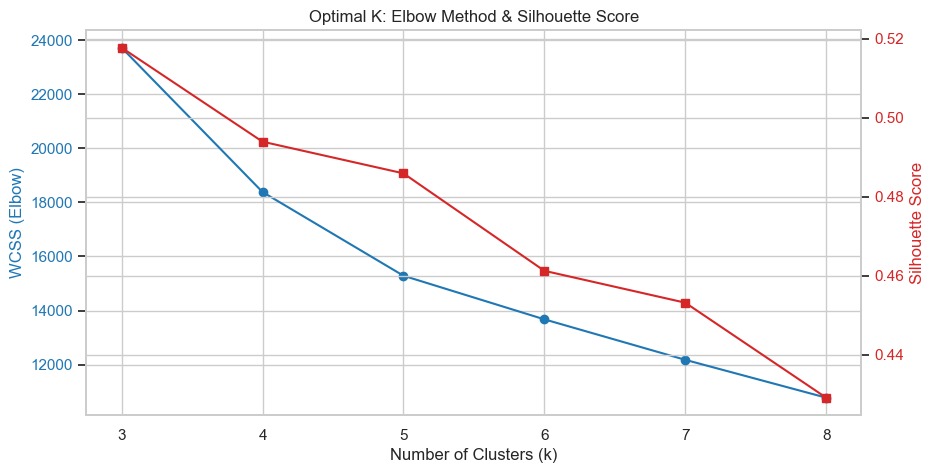

In [2167]:
# Determine optimal k using Elbow Method and Silhouette Score
wcss = [] 
sil_scores = []
k_range = range(3, 9) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, cluster_labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Elbow)', color='tab:blue')
ax1.plot(k_range, wcss, 'o-', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, sil_scores, 's-', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal K: Elbow Method & Silhouette Score')
plt.show()


Based on the plot above (usually where the Silhouette peaks or the Elbow bends), we pick our K. 
For this dataset, **K=4** is often a strong choice for business segmentation.

In [2168]:
# Based on the plots, choose optimal k and conduct k means
optimal_k = 4 
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
dropped_data['kmeans_Cluster'] = kmeans_final.fit_predict(X)

print(dropped_data['kmeans_Cluster'].value_counts())

kmeans_Cluster
3    3244
2    2883
0    1431
1     484
Name: count, dtype: int64


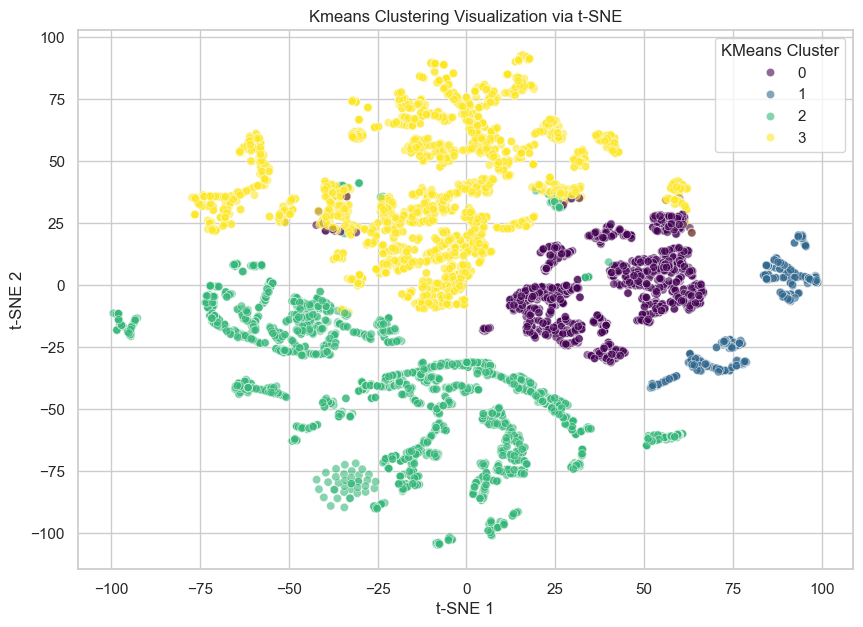

In [2169]:
# Visualize clusters using t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=dropped_data['kmeans_Cluster'],
    palette='viridis',
    alpha=0.6
)
plt.title('Kmeans Clustering Visualization via t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='KMeans Cluster')
plt.show()


In [2170]:
for i in range(optimal_k):
    kmeans_cluster_data = dropped_data[dropped_data['kmeans_Cluster'] == i]
    avg_rev = kmeans_cluster_data['Revenue (USD)'].mean() 
    avg_emp = kmeans_cluster_data['Employees Single Site'].mean() 
    top_sic = kmeans_cluster_data['SIC_2digit_Description'].value_counts().head(3).index.tolist()
    print(f"Cluster {i}: Size={len(kmeans_cluster_data)} | Avg Revenue={avg_rev:,.0f} | Avg Employees={avg_emp:,.0f} | Top SICs: {top_sic}")

Cluster 0: Size=1431 | Avg Revenue=9,678,448 | Avg Employees=11 | Top SICs: ['Accounting/auditing/bookkeeping          , Architectural services                   , Business consulting services             , Commercial nonphysical research          , Commercial physical research             , Engineering Services, Engineering services                     , Facilities support services              , Management consulting services           , Management services                      , Noncommercial research organization      , Surveying services                       , Testing laboratory                       ', 'Advertising agency                       , Advertising services                     , Building maintenance services            , Business services                        , Business services, nec, nsk              , Commercial art/graphic design            , Computer related services                , Computer systems design                  , Custom computer programming           

Cluster 0 stands out as a group of high-efficiency specialists or asset-holding firms which generate massive revenue.

Cluster 1 captures the labor-intensive utility and telecommunications sector, generating a moderate amount of revenue but require a signifcant amount of employees. 

Cluster 2 appears to represent micro-retail businesses. However, the extremely low average revenue of $271 suggests that this cluster may contain inactive companies, shell entities, or data entry errors where the revenue figures were under-reported.

Cluster 3 represents the standard mid-market operating company. These firms show a healthy balance between revenue and headcount, suggesting they are active, labor-driven organizations.

#### 5.2.2 Hierarchical Clustering
Hierarchical Clustering has been selected as it can be used to identify nested relationships and natural groupings without pre-specifying the number of clusters (k). This method allows for the inspection of a dendrogram to visualize how smaller clusters merge into larger ones, offering granular insights into potential sub-niches that K-Means might overlook.

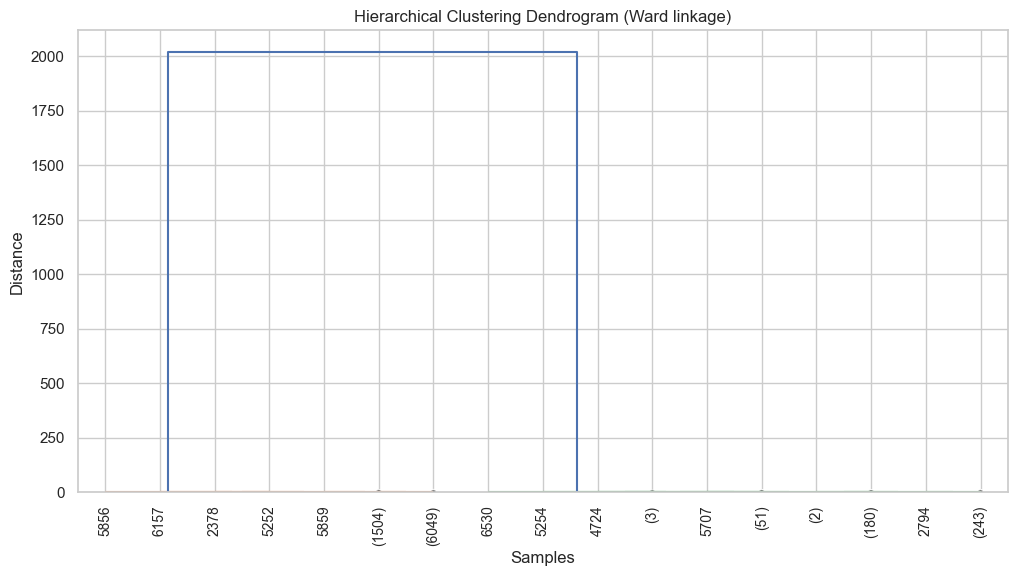

In [2171]:
# Use the same features as for K-Means
X_hc = X.copy()

# Compute linkage matrix using Ward's method (minimizes variance within clusters)
Z = linkage(X_hc, method='single')

plt.figure(figsize=(12, 6))
dendrogram(
    Z, 
    truncate_mode='level',  
    p=5,                    
    leaf_rotation=90, 
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

The dendrogram suggests that it found two extremely distinct groups, which are separated by a very large mathematical distance, represented by the height of the vertical blue lines reaching nearly 2000 on the y-axis. This suggests that the difference between these two groups is enormous compared to the relatively tiny differences found within the groups, which appear almost flat near the bottom of the chart.

Furthermore, it also suggests the presence of possible outliers primarily through the mix of labels on the x-axis.

In [2172]:
# Assign cluster labels
hc_labels = fcluster(Z, t=4, criterion='maxclust')
dropped_data['HC_Cluster'] = hc_labels

# Inspect cluster sizes
print(dropped_data['HC_Cluster'].value_counts())

HC_Cluster
1    7557
3     483
2       1
4       1
Name: count, dtype: int64


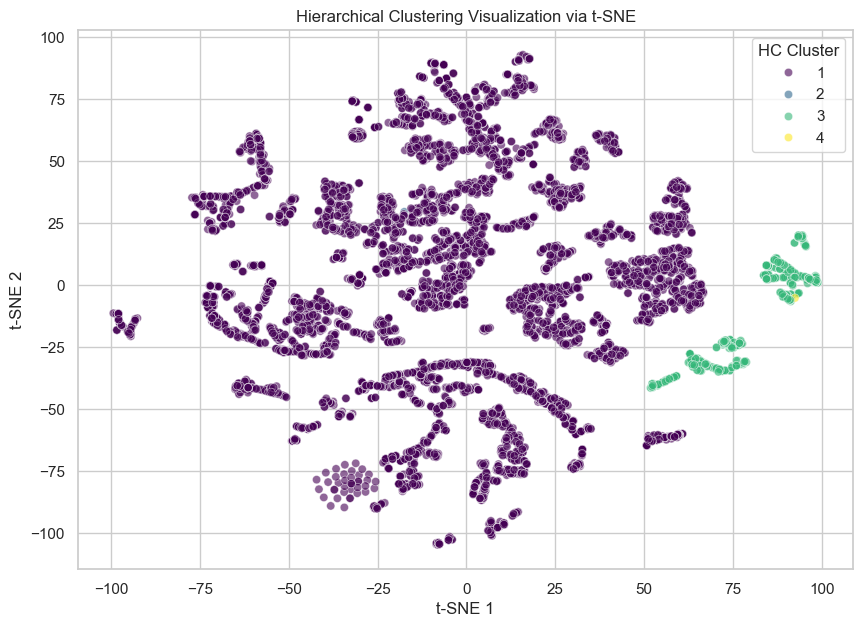

In [2173]:
#t-sne visualization
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_hc)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=dropped_data['HC_Cluster'],
    palette='viridis',
    alpha=0.6
)
plt.title('Hierarchical Clustering Visualization via t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='HC Cluster')
plt.show()



In [2174]:
for i in range(1,optimal_k + 1):
    hc_cluster_data = dropped_data[dropped_data['HC_Cluster'] == i]
    avg_rev = hc_cluster_data['Revenue (USD)'].mean() 
    avg_emp = hc_cluster_data['Employees Single Site'].mean() 
    top_sic = hc_cluster_data['SIC_2digit_Description'].value_counts().head(3).index.tolist()
    print(f"Cluster {i}: Size={len(hc_cluster_data)} | Avg Revenue={avg_rev:,.0f} | Avg Employees={avg_emp:,.0f} | Top SICs: {top_sic}")

Cluster 1: Size=7557 | Avg Revenue=4,284,928 | Avg Employees=23 | Top SICs: ['Advertising agency                       , Advertising services                     , Building maintenance services            , Business services                        , Business services, nec, nsk              , Commercial art/graphic design            , Computer related services                , Computer systems design                  , Custom computer programming              , Data processing/preparation              , Disinfecting/pest services               , Employment agency                        , Equipment rental/leasing                 , Heavy construction equipment rental      , Help supply services                     , Outdoor advertising services             , Photocopying services                    , Prepackaged software services            , Secretarial/court reporting              , Security systems services                ', 'Accounting/auditing/bookkeeping          , Architectural ser

Most of the companies, about 7,557 of them, were lumped into a single massive group (Cluster 1). This "catch-all" cluster contains nearly 94% of the dataset and mixes completely different industries like advertising, retail, and construction, which means the model failed to find meaningful differences between them.

The other clusters are extremely small and appear to be outliers. Cluster 2 contains only one single heavy construction company, while Cluster 4 contains just one metal manufacturing company with zero revenue but 1,500 employees, which is likely a data error.

Cluster 3 is the only minority group with a coherent structure, containing 483 companies that seem to be labor-intensive service firms. 

Overall, this result is poor because instead of segmenting the market, the algorithm simply grouped almost everyone together and isolated two or three weird data points.

#### 5.2.3 Hybrid Semantic-Numeric Clustering 
Given that there may be outliers and to overcome the limitations of purely financial metrics, Hybrid Semantic-Numeric Clustering has been chosen. By integrating NLP (text embeddings) with numeric data, this method groups companies based on what they do (business activity) rather than just how much they earn. The rule-based removal of "Micro" companies further ensures that the model focuses on meaningful patterns among active entities without being skewed by data noise.

In [2175]:
micro_threshold = 50000  # revenue < $50k considered micro businesses

# filter companies based on revenue and employees
micro_companies = dropped_data[dropped_data['Revenue (USD)'] < micro_threshold].copy()
active_companies = dropped_data[dropped_data['Revenue (USD)'] >= micro_threshold].copy()

print(f"Micro Companies (<${micro_threshold}): {len(micro_companies)}")
print(f"Active Companies (≥${micro_threshold}): {len(active_companies)}")

Micro Companies (<$50000): 3298
Active Companies (≥$50000): 4744


In [2176]:
X_active = active_companies[features_for_clustering].values 

active_companies['combined_text'] = (
    active_companies['Company Description'].fillna('') 
)

model = SentenceTransformer('all-MiniLM-L6-v2')
text_embeddings = model.encode(active_companies['combined_text'].tolist(), show_progress_bar=True)

combined_features = np.hstack([X_active, text_embeddings])
print(f"Combined feature matrix shape (active companies only): {combined_features.shape}")

Batches: 100%|██████████| 149/149 [00:19<00:00,  7.78it/s]


Combined feature matrix shape (active companies only): (4744, 401)


In [2177]:
pca = PCA(n_components=50, random_state=42)
pca_features = pca.fit_transform(combined_features)

print(pca_features.shape)

(4744, 50)


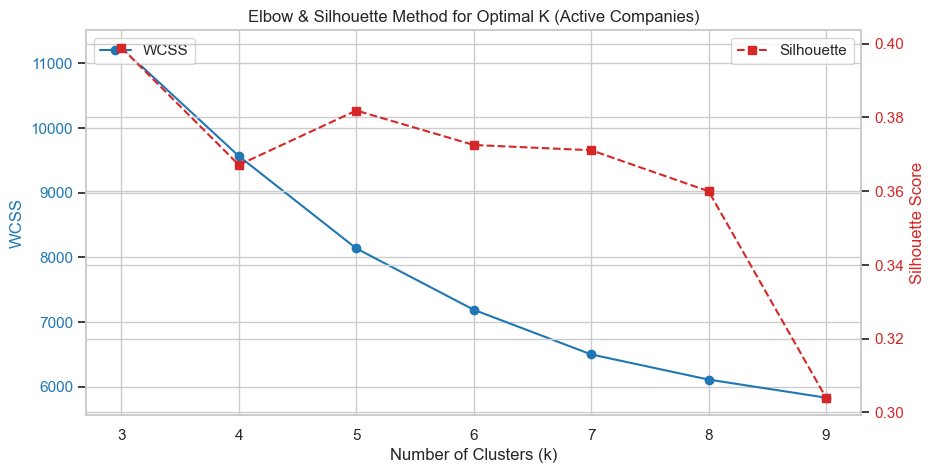

In [2178]:
# Determine optimal k using Elbow Method and Silhouette Score for active companies
wcss = []
sil_scores = []
k_range = range(3, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_features)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(pca_features, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, wcss, 'o-', color='tab:blue', label='WCSS')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's--', color='tab:red', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow & Silhouette Method for Optimal K (Active Companies)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

From the result above, we can see that the optimal k is 5 since it shows a clear elbow in the WCSS curve (where the rate of decrease starts to level off) and the highest silhouette score among the tested values, indicating the best balance between cluster compactness and separation.

In [2179]:
optimal_k = 5
kmeans_hybrid = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
active_companies['hybrid_Cluster'] = kmeans_hybrid.fit_predict(pca_features)
print(f"Active Companies Cluster Sizes:\n{active_companies['hybrid_Cluster'].value_counts()}")

Active Companies Cluster Sizes:
hybrid_Cluster
0    2288
2    1254
3     656
4     309
1     237
Name: count, dtype: int64


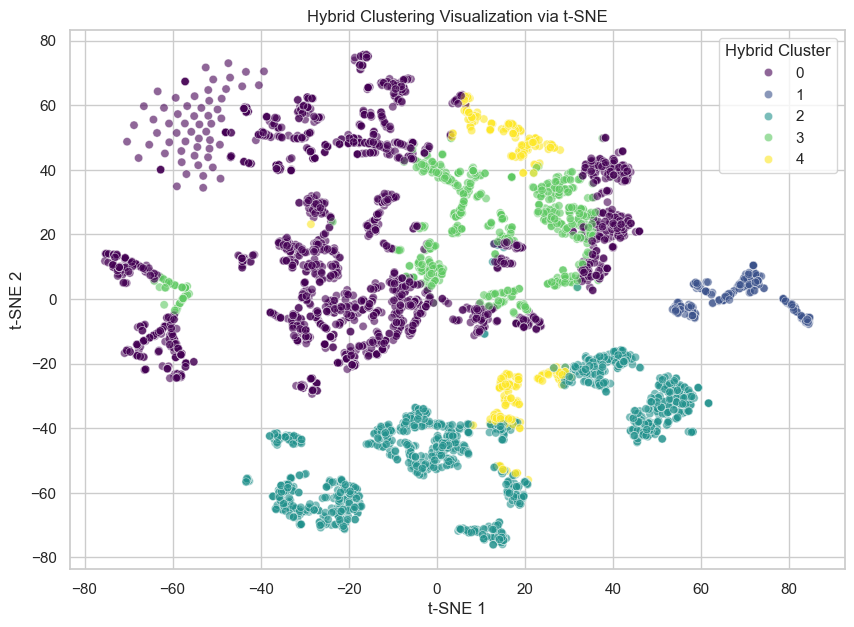

In [2180]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(pca_features)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=active_companies['hybrid_Cluster'],
    palette='viridis',
    alpha=0.6
)
plt.title('Hybrid Clustering Visualization via t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Hybrid Cluster')
plt.show()


The Blue and Teal clusters are completely separated from the main mass of points. This highlights the differentiation between hard industries such as Manufacturing from soft industries such as Services, thus proving that the text embeddings have been succesful.

Meanwhile, the Purple, Green and Yellow clusters form a connected but segmented shape for the service industries. Since there are many types of services provided, hence, the clusters are also separated in a distinct manner.

In [2181]:
micro_companies['hybrid_Cluster'] = 'Micro'
final_clusters = pd.concat([active_companies, micro_companies], axis=0)

print(final_clusters['hybrid_Cluster'].value_counts())

hybrid_Cluster
Micro    3298
0        2288
2        1254
3         656
4         309
1         237
Name: count, dtype: int64


In [2182]:
for label in final_clusters['hybrid_Cluster'].unique():
    cluster_data = final_clusters[final_clusters['hybrid_Cluster'] == label]
    avg_rev = cluster_data['Revenue (USD)'].mean()
    avg_emp = cluster_data['Employees Single Site'].mean()
    top_sic = cluster_data['SIC_2digit_Description'].value_counts().head(3).index.tolist()
    print(f"Cluster {label}: Size={len(cluster_data)} | Avg Revenue={avg_rev:,.0f} | Avg Employees={avg_emp:,.0f} | Top SICs: {top_sic}")

Cluster 0: Size=2288 | Avg Revenue=3,344,210 | Avg Employees=23 | Top SICs: ['Advertising agency                       , Advertising services                     , Building maintenance services            , Business services                        , Business services, nec, nsk              , Commercial art/graphic design            , Computer related services                , Computer systems design                  , Custom computer programming              , Data processing/preparation              , Disinfecting/pest services               , Employment agency                        , Equipment rental/leasing                 , Heavy construction equipment rental      , Help supply services                     , Outdoor advertising services             , Photocopying services                    , Prepackaged software services            , Secretarial/court reporting              , Security systems services                ', 'Accounting/auditing/bookkeeping          , Architectural ser

Cluster 0 represents the core "General Services" sector, containing the bulk of standard B2B companies in advertising, IT, and accounting with moderate revenue. 

Cluster 1 appears to be a niche subset of this group, likely separated by the text analysis because these firms focus specifically on infrastructure and communications, as evidenced by the unique presence of cable TV and telegraph services in their top categories. 

Cluster 2 and Cluster 3 demonstrate a powerful distinction in business models. Both groups earn roughly $10 million in revenue, but Cluster 2 is an "High-Efficiency" group that achieves this with only 7 employees, likely representing asset-holding firms or elite consultancies. In contrast, Cluster 3 is a "High-Operation" group that requires 25 employees to generate the same amount of money, indicating a more traditional, labor-intensive workforce.

Cluster 4 is the standout success of this method, clearly isolating the big Industrial companies in manufacturing and heavy construction. 

Finally, the Micro Cluster successfully captures the low-revenue retail businesses and data noise, ensuring they do not skew the statistics of the active commercial groups.

In [1535]:
#save final clustered data 
final_clusters.to_pickle('../data/clustered_companies.pkl')